# PURITY Training

Config-driven training/HPO/eval/export notebook for the PURITY plugin.

In [1]:
from __future__ import annotations

import sys
from datetime import datetime
from pathlib import Path

from pioneerml.integration.zenml import load_step_output
from pioneerml.integration.zenml import utils as zenml_utils

PROJECT_ROOT = zenml_utils.setup_repo_pythonpath(Path(zenml_utils.find_project_root()).resolve())
from pioneerml_purity_plugin.purity.pipeline import load_config, training_pipeline

zenml_utils.setup_zenml_for_notebook(root_path=PROJECT_ROOT, use_in_memory=True)
sys.path.insert(0, str(PROJECT_ROOT / 'artifacts'))
from generate_purity_dummy_parquet import generate_dummy_purity_parquet

print('Project root:', PROJECT_ROOT)


Using ZenML repository root: /workspace
Ensure this is the top-level of your repo (.zen must live here).
Project root: /workspace


## Build Dummy Parquet

In [2]:
dummy_parquet = PROJECT_ROOT / 'artifacts' / 'purity_notebook_train.parquet'
generate_dummy_purity_parquet(output_path=dummy_parquet, num_events=96, seed=21)
dummy_parquet

PosixPath('/workspace/artifacts/purity_notebook_train.parquet')

## Load + Patch Plugin Config

In [3]:
cfg = load_config()['training']

def patch_loader_sources(section_cfg: dict, source_path: Path) -> None:
    lm = dict(section_cfg.get('loader_manager') or {})
    lm_cfg = dict(lm.get('config') or {})
    spec = dict(lm_cfg.get('input_sources_spec') or {})
    spec['main_sources'] = [str(source_path)]
    spec['optional_sources_by_name'] = {}
    spec['source_type'] = 'file'
    lm_cfg['input_sources_spec'] = spec
    lm['config'] = lm_cfg
    section_cfg['loader_manager'] = lm

for name in ('hpo', 'train', 'evaluate', 'export'):
    sec = dict(cfg.get(name) or {})
    patch_loader_sources(sec, dummy_parquet)
    cfg[name] = sec

stamp = datetime.utcnow().strftime('%Y%m%d_%H%M%S')
cfg['hpo']['hpo']['config']['enabled'] = False
cfg['hpo']['hpo']['config']['n_trials'] = 1
cfg['hpo']['hpo']['config']['seed'] = 0
cfg['hpo']['hpo']['config']['storage'] = None
cfg['hpo']['hpo']['config']['study_name'] = f'purity_nb_hpo_{stamp}'
cfg['train']['trainer']['config']['trainer_kwargs']['max_epochs'] = 20
cfg['train']['trainer']['config']['early_stopping']['enabled'] = False

# Small notebook smoke run parity defaults:
# - keep Omar staged training behavior
# - skip evaluator (known flaky on tiny synthetic data)
cfg['train']['staged_training']['enabled'] = True
cfg['evaluate']['enabled'] = False

export_cfg = dict(cfg['export']['exporter']['config'])
export_cfg['export_dir'] = str(PROJECT_ROOT / 'artifacts' / 'purity_notebook_export')
export_cfg['filename_prefix'] = f'purity_notebook_{stamp}'
cfg['export']['exporter']['config'] = export_cfg

cfg.keys()

dict_keys(['hpo', 'train', 'evaluate', 'export'])

## Run Training Pipeline

In [4]:
run = training_pipeline.with_options(enable_cache=False)(pipeline_config=cfg)

Initiating a new run for the pipeline: training_pipeline.
Caching is disabled by default for training_pipeline.
Using user: default
Using stack: default
  deployer: default
  artifact_store: default
  orchestrator: default
You can visualize your pipeline runs in the ZenML Dashboard. In order to try it locally, please run zenml login --local.
Step tune_model has started.
Step tune_model has finished in 0.230s.
Step train_model has started.
[train_model] GPU available: True (cuda), used: True
[train_model] TPU available: False, using: 0 TPU cores
[train_model] 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
[train_model] [purity_staged_training] phase=atar_bootstrap freeze_all=False trainable_patterns=0 freeze_patterns=0 unfreeze_patterns=0 trainable_parameters=6164378 frozen_parameters=0
[train_model] GPU av

┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ PurityModel       │  6.2 M │ train │     0 │
│ 1 │ loss_fn │ PurityUnifiedLoss │      0 │ train │     0 │
└───┴─────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 6.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.2 M                                                                                                
Total estimated model params size (MB): 24                                                                         
Modules in train mode: 318                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

[train_model] Trainer.fit stopped: max_epochs=8 reached.


...

┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ PurityModel       │  6.2 M │ train │     0 │
│ 1 │ loss_fn │ PurityUnifiedLoss │      0 │ train │     0 │
└───┴─────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 6.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.2 M                                                                                                
Total estimated model params size (MB): 24                                                                         
Modules in train mode: 318                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

[train_model] Trainer.fit stopped: max_epochs=6 reached.


[train_model] [purity_staged_training] phase=event_fusion train_loss_points=6 val_loss_points=7
Step train_model has finished in 31.893s.
Step evaluate_model has started.
Step evaluate_model has finished in 0.169s.
Step export_model has started.
Step export_model has finished in 2.941s.
Pipeline run has finished in 37.212s.


### Training Curves
Quick visual check that train/val loss behaves as expected.


hpo: {}
metrics keys: ['skipped']
metrics: skipped (disabled for notebook smoke data)
export: {'torchscript_path': '/workspace/artifacts/purity_notebook_export/purity_notebook_20260415_234931_20260415_235007_torchscript.pt', 'metadata_path': '/workspace/artifacts/purity_notebook_export/purity_notebook_20260415_234931_20260415_235007_meta.json', 'export_type': 'script', 'exporter_type': 'torchscript'}


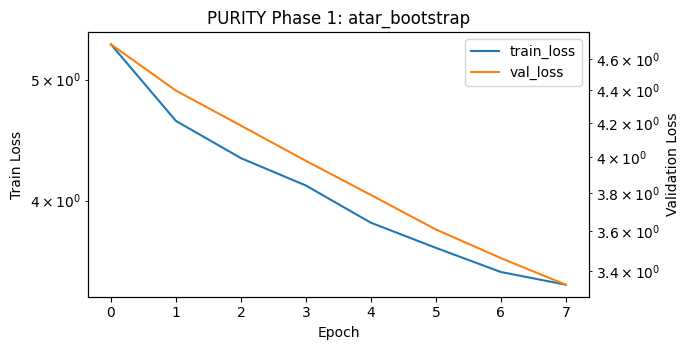

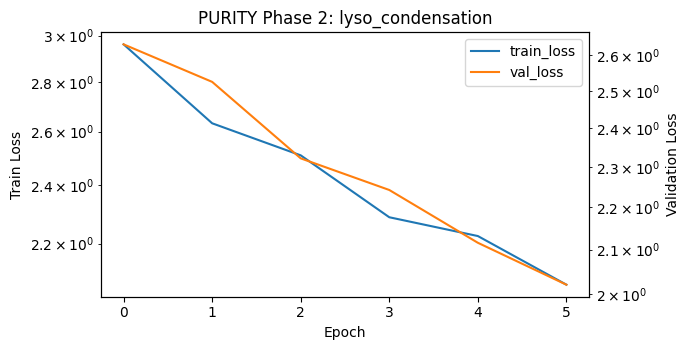

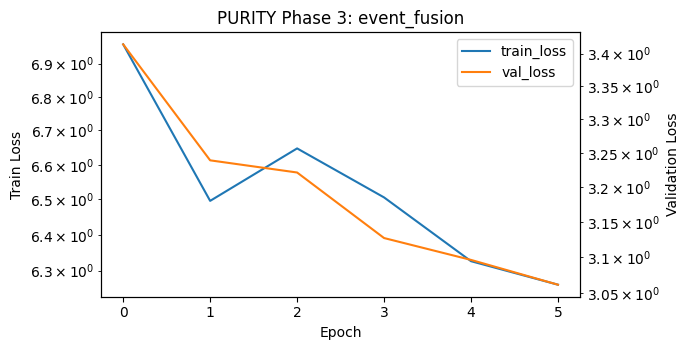

In [5]:
from pioneerml.evaluation.plots import plot_loss_curves
from pioneerml_purity_plugin.purity.evaluation.plots import (
    plot_purity_phase_1_loss_curves,
    plot_purity_phase_2_loss_curves,
    plot_purity_phase_3_loss_curves,
)

hpo_output = load_step_output(run, 'tune_model')
train_output = load_step_output(run, 'train_model')
if bool((cfg.get('evaluate') or {}).get('enabled', True)):
    eval_output = load_step_output(run, 'evaluate_model')
else:
    eval_output = {'metrics': {'skipped': 'evaluation disabled by config'}}
export_output = load_step_output(run, 'export_model')

metrics = dict((eval_output or {}).get('metrics') or {})
print('hpo:', (hpo_output or {}).get('hpo_params'))
print('metrics keys:', sorted(metrics.keys()))
if metrics and 'skipped' not in metrics:
    parity_keys = [
        'loss_total', 'loss_atar_slice_multi', 'loss_node_pdg', 'loss_atar_edge',
        'loss_slice_pdg', 'loss_endpoints', 'loss_lyso_condensation', 'loss_event_builder',
    ]
    print('selected metrics:', {k: metrics.get(k) for k in parity_keys if k in metrics})
else:
    print('metrics: skipped (disabled for notebook smoke data)')
print('export:', export_output)

trained_module = (train_output or {}).get('module') if isinstance(train_output, dict) else None
if trained_module is None:
    raise RuntimeError('train_output is missing module; cannot plot loss curves.')

phase_histories = list(getattr(trained_module, 'staged_phase_loss_histories', []) or [])

# Omar-parity staged curriculum uses 3 phases by default.
# Render one figure per phase so we can inspect each stage independently.
if len(phase_histories) >= 3:
    plot_purity_phase_1_loss_curves(module=trained_module, show=True)
    plot_purity_phase_2_loss_curves(module=trained_module, show=True)
    plot_purity_phase_3_loss_curves(module=trained_module, show=True)
else:
    print(f'Expected >=3 phase histories, found {len(phase_histories)}; falling back to aggregate loss plot.')
    plot_loss_curves(
        getattr(trained_module, 'train_epoch_loss_history', []),
        getattr(trained_module, 'val_epoch_loss_history', []),
        title='PURITY: Loss Curves',
        show=True,
    )
